In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn

In [139]:
e_class = pd.read_csv("/Users/juliana-figueroa/Desktop/DSC-515/online_classroom_data.csv")

In [140]:
e_class.head(10)

,Unnamed: 0,total_posts,helpful_post,nice_code_post,collaborative_post,confused_post,creative_post,bad_post,amazing_post,timeonline,sk1_classroom,sk2_classroom,sk5_classroom,sk3_classroom,sk4_classroom,Approved
0,0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,1.0,1600.0,"2,1","2,4","3,5","3,6","1,7",0
1,1,1.0,0.0,0.0,1.0,0.0,2.0,0.0,3.0,592.0,"0,3","0,3",0,"0,1","0,2",0
2,2,2.0,4.0,3.0,9.0,0.0,16.0,1.0,8.0,1110.0,8,5,5,7,5,1
3,3,5.0,1.0,3.0,9.0,2.0,11.0,0.0,8.0,8651.0,6,5,4,6,4,1
4,4,14.0,6.0,15.0,28.0,0.0,50.0,0.0,45.0,34172.0,"8,7",9,"6,5",10,"8,8",1
5,5,9.0,3.0,9.0,16.0,7.0,21.0,0.0,17.0,14985.0,"5,1",6,5,"7,5","8,6",1
6,6,15.0,10.0,21.0,21.0,1.0,34.0,0.0,37.0,25897.0,"4,7",5,2,5,"8,8",1
7,7,8.0,9.0,21.0,20.0,0.0,31.0,0.0,28.0,9476.0,"5,3","5,7",4,"5,7","8,4",1
8,8,6.0,3.0,12.0,13.0,0.0,24.0,0.0,19.0,43612.0,10,"8,4",10,10,"9,6",1
9,9,4.0,4.0,1.0,3.0,0.0,15.0,0.0,14.0,4791.0,"2,3","2,6",1,"2,9",7,0


In [141]:
e_class.shape

(71, 16)

In [142]:
e_class.describe()

,Unnamed: 0,total_posts,helpful_post,nice_code_post,collaborative_post,confused_post,creative_post,bad_post,amazing_post,timeonline,Approved
count,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000,71.000000
mean,35.000000,5.507042,4.028169,7.478873,11.366197,0.549296,18.309859,0.056338,18.957746,10279.126761,0.704225
std,20.639767,6.480461,6.843082,12.746831,13.970622,1.350013,21.930795,0.287219,22.086477,10176.243372,0.459639
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.500000,2.000000,0.000000,0.000000,1.500000,0.000000,6.500000,0.000000,7.000000,1627.500000,0.000000
50%,35.000000,4.000000,3.000000,2.000000,7.000000,0.000000,14.000000,0.000000,16.000000,7664.000000,1.000000
75%,52.500000,7.500000,5.500000,12.500000,16.000000,0.000000,24.000000,0.000000,25.500000,16574.000000,1.000000
max,70.000000,46.000000,53.000000,90.000000,89.000000,7.000000,150.000000,2.000000,155.000000,43612.000000,1.000000


In [143]:
print(e_class.isnull().sum())
print("There are no missing values in this dataset! --- No need to handle missing values.")

Unnamed: 0            0
total_posts           0
helpful_post          0
nice_code_post        0
collaborative_post    0
confused_post         0
creative_post         0
bad_post              0
amazing_post          0
timeonline            0
sk1_classroom         0
sk2_classroom         0
sk5_classroom         0
sk3_classroom         0
sk4_classroom         0
Approved              0
dtype: int64
There are no missing values in this dataset! --- No need to handle missing values.


# OBJECTIVE
For this project, I will use a classification model to predict whether a student is *"Approved"* or *"Not Approved"* based on their classroom activity, peer reactions, time online, total posts, and skill evaluation scores. I will also explore whether peer reactions show overall classroom sentiment, whether some students receive more support than others, and whether engagement is more influenced by time online, posting frequency, skill quality, or specific emoji reactions.

### Key Questions
-How are students performing overall based on peer reactions? 

-Is there a relationship between time spent in the classroom environment and the type of reactions received?

-Do students who spend more time in the classroom environment get more reactions?

-Which emojis are most common among students with high VS low time?

-Is there a point where more effort doesn’t lead to more recognition?

-Is student engagement (reactions) driven more by time spent online, posting frequency, or the quality of contributions?

-Is there a correlation between peer reactions and skill development?

-Are certain skills more strongly associated with higher engagement or approval?

-Which factors (skills, reactions, engagement) are most strongly related to being approved in the class?


In [144]:
# Unnamed/index column will not be needed, so it gets dropped
df = e_class.drop(columns=["Unnamed: 0"], errors="ignore")

In [145]:
# Some values have decimal commas, so they get converted to decimal points
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str).str.replace(",",".", regex=False)
        df[col] = pd.to_numeric(df[col])

## Feature Engineering

In order to answer questions such as "What is the overall sentiment in the classroom (positive, negative)?", "Do students who spend more time in the classroom environment get more reactions?", "Is there a point where more effort doesn’t lead to more recognition?", or "Are certain skills more strongly associated with higher engagement or approval?" --- The need to create features is prevalent. Next section will create these features. Additionally, we want to keep in mind what each skill evaluation means from a scale of 0 to 10.

-*Critical Thinking and Problem Solving Skills* - named as **SK1**

-*Creativity and Innovation Skills* - named as **SK2**

-*Constant and Self Learning Skills* - named as **SK3**

-*Collaboration and Self-Direction Skills* - named as **SK4**

-*Social and Cultural Responsibility* - named as **SK5**

In [146]:
# Classifying Positive VS Negative Reactions

positive_reactions = [
    "helpful_post","nice_code_post","collaborative_post","creative_post","amazing_post"
]

negative_reactions = ["confused_post", "bad_post"]

In [147]:
# Creating New Sentiment Features

df["positive_reactions"] = df[positive_reactions].sum(axis=1)
df["negative_reactions"] = df[negative_reactions].sum(axis=1)
df["total_reactions"] = df[positive_reactions + negative_reactions].sum(axis=1)

# Engagement Quality
df["reactions_per_posts"] = df["total_reactions"] / df["total_posts"].replace(0, np.nan)

# Positive Sentiment Ratio
df["positive_reaction_ratio"] = df["positive_reactions"] / df["total_reactions"].replace(0, np.nan)

df[["reactions_per_posts", "positive_reaction_ratio"]] = df[
    ["reactions_per_posts", "positive_reaction_ratio"]
].fillna(0)

In [148]:
# Creating Skill Features

skill_cols = [
    "sk1_classroom",
    "sk2_classroom",
    "sk3_classroom",
    "sk4_classroom",
    "sk5_classroom"
]

df["skill_average"] = df[skill_cols].mean(axis=1)

print(df[skill_cols + ["Approved"]].corr()["Approved"].sort_values(ascending=False))

Approved         1.000000
sk3_classroom    0.899386
sk2_classroom    0.892099
sk1_classroom    0.891742
sk4_classroom    0.846737
sk5_classroom    0.843320
Name: Approved, dtype: float64


In [149]:
# Features that answer key questions


# Effort efficiency
df["reactions_per_time"] = df["total_reactions"] / df["timeonline"].replace(0, 1)

# Skill strength (variation)
df["skill_std"] = df[skill_cols].std(axis=1)

In [150]:
df.head(10)

,total_posts,helpful_post,nice_code_post,collaborative_post,confused_post,creative_post,bad_post,amazing_post,timeonline,sk1_classroom,...,sk4_classroom,Approved,positive_reactions,negative_reactions,total_reactions,reactions_per_posts,positive_reaction_ratio,skill_average,reactions_per_time,skill_std
0,1.0,0.0,0.0,0.0,0.0,6.0,0.0,1.0,1600.0,2.1,...,1.7,0,7.0,0.0,7.0,7.000000,1.000000,2.66,0.004375,0.850294
1,1.0,0.0,0.0,1.0,0.0,2.0,0.0,3.0,592.0,0.3,...,0.2,0,6.0,0.0,6.0,6.000000,1.000000,0.18,0.010135,0.130384
2,2.0,4.0,3.0,9.0,0.0,16.0,1.0,8.0,1110.0,8.0,...,5.0,1,40.0,1.0,41.0,20.500000,0.975610,6.00,0.036937,1.414214
3,5.0,1.0,3.0,9.0,2.0,11.0,0.0,8.0,8651.0,6.0,...,4.0,1,32.0,2.0,34.0,6.800000,0.941176,5.00,0.003930,1.000000
4,14.0,6.0,15.0,28.0,0.0,50.0,0.0,45.0,34172.0,8.7,...,8.8,1,144.0,0.0,144.0,10.285714,1.000000,8.60,0.004214,1.282576
5,9.0,3.0,9.0,16.0,7.0,21.0,0.0,17.0,14985.0,5.1,...,8.6,1,66.0,7.0,73.0,8.111111,0.904110,6.44,0.004872,1.569395
6,15.0,10.0,21.0,21.0,1.0,34.0,0.0,37.0,25897.0,4.7,...,8.8,1,123.0,1.0,124.0,8.266667,0.991935,5.10,0.004788,2.422808
7,8.0,9.0,21.0,20.0,0.0,31.0,0.0,28.0,9476.0,5.3,...,8.4,1,109.0,0.0,109.0,13.625000,1.000000,5.82,0.011503,1.602186
8,6.0,3.0,12.0,13.0,0.0,24.0,0.0,19.0,43612.0,10.0,...,9.6,1,71.0,0.0,71.0,11.833333,1.000000,9.60,0.001628,0.692820
9,4.0,4.0,1.0,3.0,0.0,15.0,0.0,14.0,4791.0,2.3,...,7.0,0,37.0,0.0,37.0,9.250000,1.000000,3.16,0.007723,2.265612


In [151]:
# Effort VS Recognition Correlation

df[["timeonline", "total_reactions"]].corr()

,timeonline,total_reactions
timeonline,1.000000,0.689833
total_reactions,0.689833,1.000000


In [152]:
# Do certain emojis depend on time?

for col in [
    "helpful_post",
    "nice_code_post",
    "collaborative_post",
    "confused_post",
    "creative_post",
    "bad_post",
    "amazing_post"
]:
    print(col, df[["timeonline", col]].corr().iloc[0,1])

helpful_post 0.5734396513829881
nice_code_post 0.605448431832267
collaborative_post 0.6944392770128786
confused_post 0.2535240824565685
creative_post 0.6905082058347407
bad_post 0.08973490844138048
amazing_post 0.6861036425063618


In [153]:
print("Overall Approval Rate")
print(df["Approved"].value_counts(normalize=True))

print("\nCorrelations with Approved")
print(df.corr()["Approved"].sort_values(ascending=False))

print("\nCorrelations with Total Reactions")
print(df.corr()["total_reactions"].sort_values(ascending=False))

Overall Approval Rate
Approved
1    0.704225
0    0.295775
Name: proportion, dtype: float64

Correlations with Approved
Approved                   1.000000
skill_average              0.920713
sk3_classroom              0.899386
sk2_classroom              0.892099
sk1_classroom              0.891742
sk4_classroom              0.846737
sk5_classroom              0.843320
positive_reaction_ratio    0.650037
reactions_per_posts        0.617393
timeonline                 0.568298
collaborative_post         0.466496
creative_post              0.442885
total_posts                0.439544
total_reactions            0.436846
amazing_post               0.434987
positive_reactions         0.434348
nice_code_post             0.351249
helpful_post               0.325159
negative_reactions         0.272815
reactions_per_time         0.272668
skill_std                  0.272514
confused_post              0.265566
bad_post                   0.128024
Name: Approved, dtype: float64

Correlations with To

In [154]:
# What influences class approval the most?

df[["timeonline", "positive_reactions", "skill_average", "Approved"]].corr()

,timeonline,positive_reactions,skill_average,Approved
timeonline,1.000000,0.689307,0.618938,0.568298
positive_reactions,0.689307,1.000000,0.529754,0.434348
skill_average,0.618938,0.529754,1.000000,0.920713
Approved,0.568298,0.434348,0.920713,1.000000


# ---*Visualizations*---

### How are students performing overall based on peer reactions?

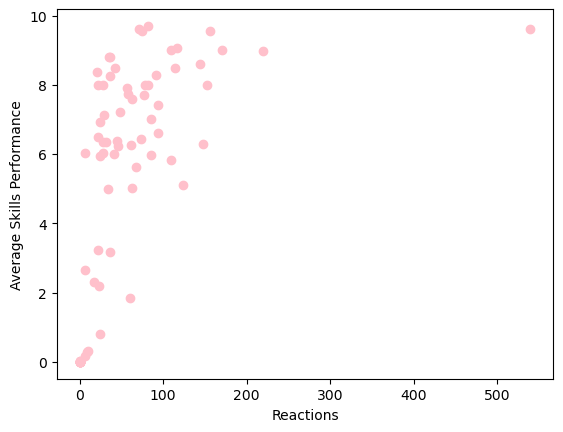

In [155]:
plt.scatter(df["total_reactions"], df["skill_average"], color='pink')
plt.xlabel("Reactions")
plt.ylabel("Average Skills Performance")
plt.show()

### Is there a relationship between time spent in the classroom environment and the type of reactions received?

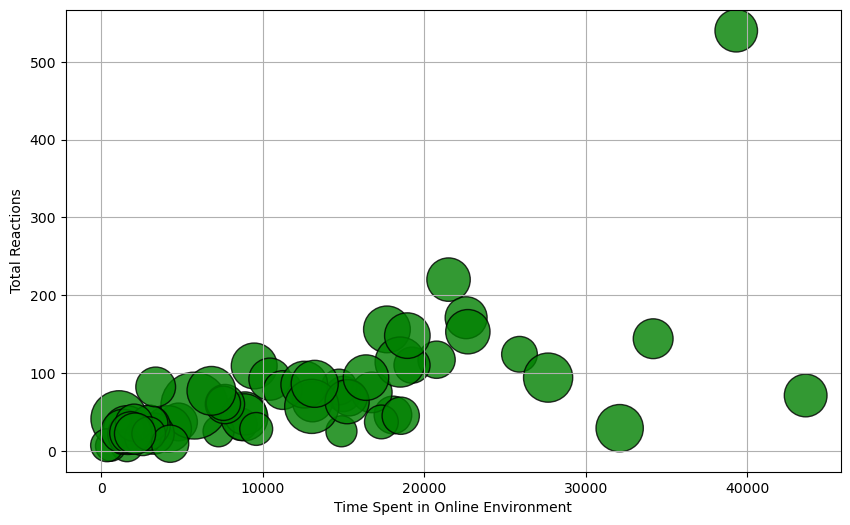

In [156]:
plot_df = df[["timeonline","total_reactions","reactions_per_posts","positive_reaction_ratio",]].dropna()

colors = []

for value in plot_df['positive_reaction_ratio']:
    if value >= 0.8:
        colors.append('green')
    elif value >= 0.5:
        colors.append('orange')
    else:
        colors.append('red')

# Bubble Chart
plt.figure(figsize=(10,6))

plt.scatter(plot_df['timeonline'],plot_df['total_reactions'], s=plot_df['reactions_per_posts'] * 80, c=colors, alpha=0.8, edgecolors='black')
plt.xlabel("Time Spent in Online Environment")
plt.ylabel("Total Reactions")
plt.grid(True)
plt.show()

### Do students who spend more time in the online environment get more reactions?

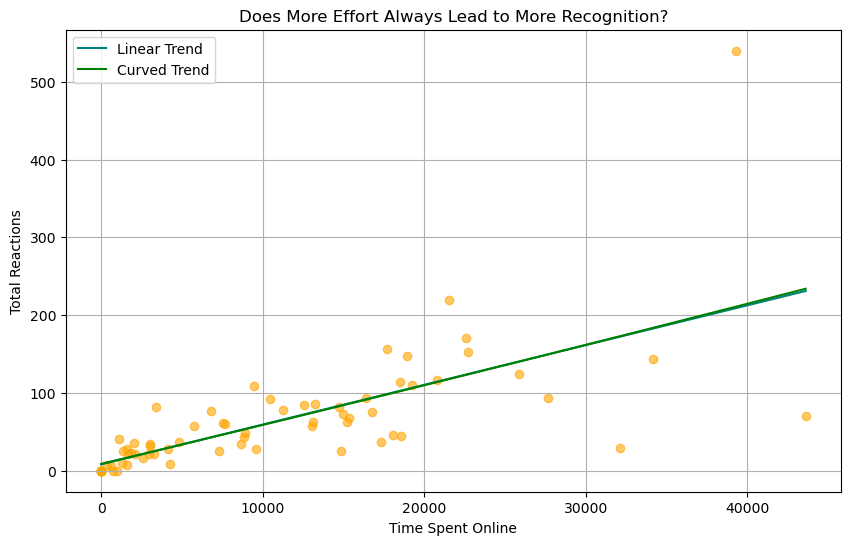

The curve does not show a clear leveling-off point.


In [157]:

plot_df = df[['timeonline', 'total_reactions']].dropna()

x = plot_df['timeonline']
y = plot_df['total_reactions']

plt.figure(figsize=(10,6))
plt.scatter(x, y, alpha=0.6, color='orange')

# Regression line (trend line)
linear_fit = np.polyfit(x, y, 1)  # linear fit
linear_model = np.poly1d(linear_fit)

# Curved trend line
curve_fit = np.polyfit(x, y, 2)
curve_model = np.poly1d(curve_fit)

x_sorted = np.sort(x)

plt.plot(x_sorted, linear_model(x_sorted), label='Linear Trend', color='teal')
plt.plot(x_sorted, curve_model(x_sorted), label='Curved Trend', color='green')

plt.xlabel('Time Spent Online')
plt.ylabel('Total Reactions')
plt.title('Does More Effort Always Lead to More Recognition?')
plt.legend()
plt.grid(True)
plt.show()

# Estimated turning point
a, b, c = curve_fit

if a < 0:
    turning_point = -b / (2 * a)
    print("Estimated point where recognition may level off or peak:", round(turning_point, 2))
else:
    print("The curve does not show a clear leveling-off point.")

### Which emojis are most common among students with high VS low time?

            helpful_post  nice_code_post  collaborative_post  creative_post  \
time_group                                                                    
Low Time        1.500000        1.666667            3.666667       7.472222   
High Time       6.628571       13.457143           19.285714      29.457143   

            amazing_post  confused_post  bad_post  
time_group                                         
Low Time        7.500000       0.138889  0.027778  
High Time      30.742857       0.971429  0.085714  


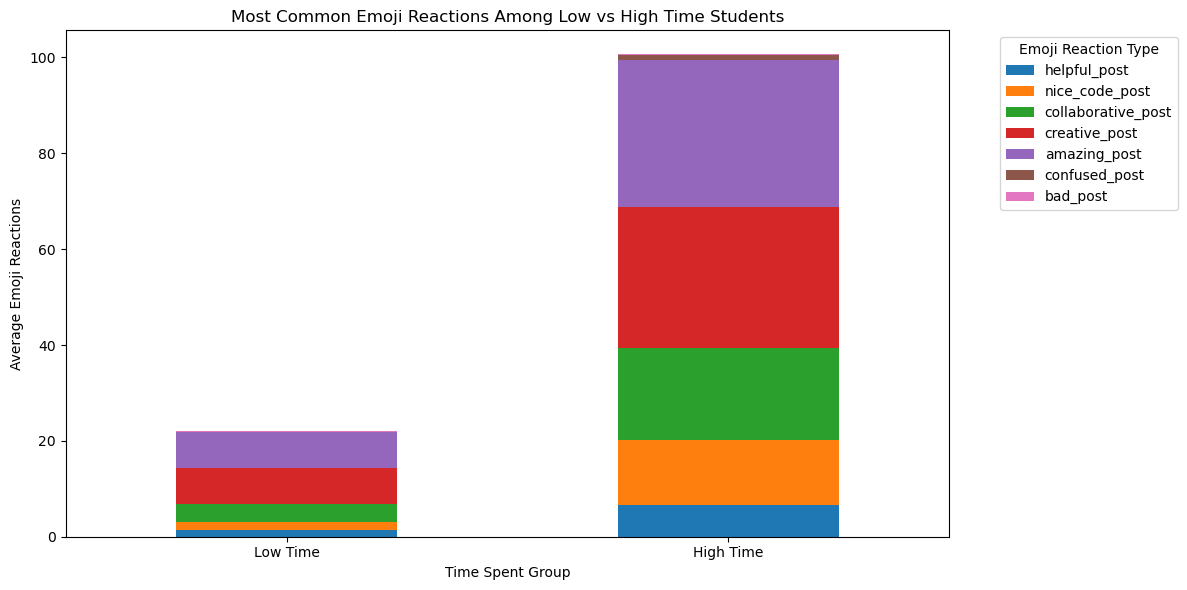

In [158]:

reaction_types = positive_reactions + negative_reactions

plot_df = df[['timeonline'] + reaction_types].dropna().copy()

# Creating Low Time and High Time groups
plot_df['time_group'] = pd.qcut(
    plot_df['timeonline'],
    q=2,
    labels=['Low Time', 'High Time']
)

# Average emoji counts by time group
emoji_by_time = plot_df.groupby('time_group', observed=False)[reaction_types].mean()
print(emoji_by_time)

# Stacked bar chart
emoji_by_time.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.xlabel('Time Spent Group')
plt.ylabel('Average Emoji Reactions')
plt.title('Most Common Emoji Reactions Among Low vs High Time Students')
plt.xticks(rotation=0)
plt.legend(title='Emoji Reaction Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Is student engagement driven more by time spent online, posting frequency, or quality of contributions?

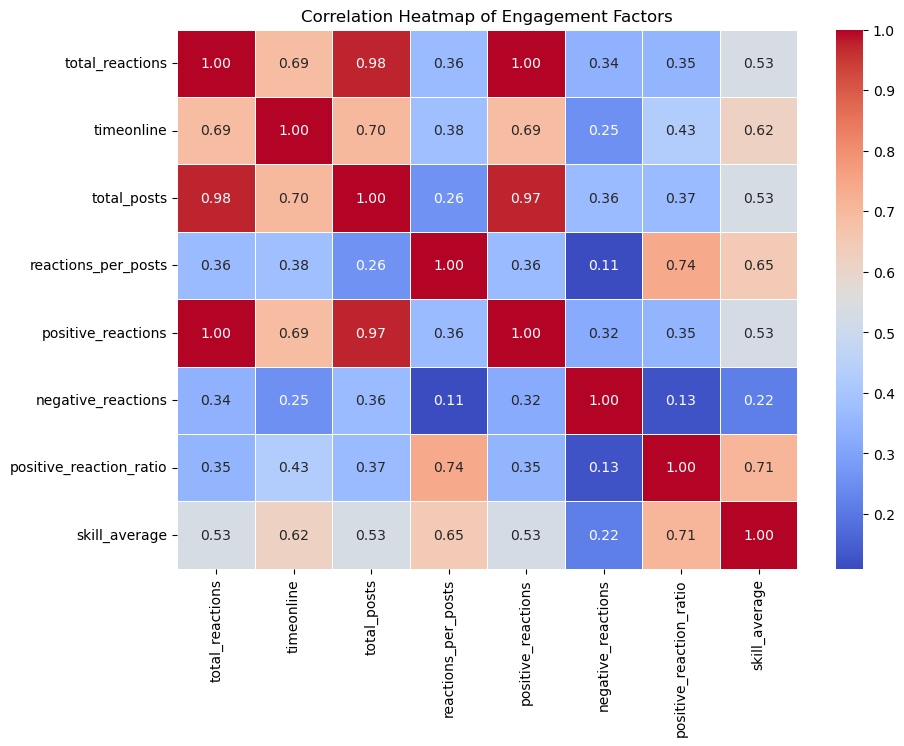

In [159]:
import seaborn as sns

# Selecting variables related to engagement
corr_columns = [
    'total_reactions',          # engagement outcome
    'timeonline',               # time spent online
    'total_posts',              # posting frequency
    'reactions_per_posts',      # quality/engagement per post
    'positive_reactions',
    'negative_reactions',
    'positive_reaction_ratio',
    'skill_average'
]

# Correlation matrix
corr_df = df[corr_columns].dropna()
correlation_matrix = corr_df.corr()

# Heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Engagement Factors')
plt.show()

### Is there a correlation between peer reactions and skill development?

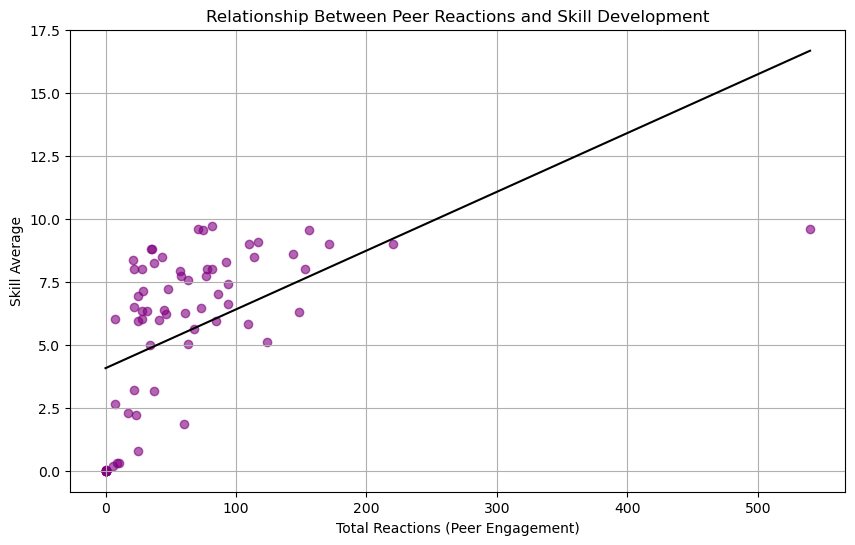

In [160]:

plot_df = df[['total_reactions', 'skill_average']].dropna()

x = plot_df['total_reactions']
y = plot_df['skill_average']

plt.figure(figsize=(10,6))

plt.scatter(x, y, alpha=0.6, color='purple')

# Trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

x_sorted = np.sort(x)
plt.plot(x_sorted, p(x_sorted), color='black')

plt.xlabel('Total Reactions (Peer Engagement)')
plt.ylabel('Skill Average')
plt.title('Relationship Between Peer Reactions and Skill Development')
plt.grid(True)
plt.show()

In [161]:
correlation = x.corr(y)
print("Correlation between reactions and skill:", round(correlation, 2))

Correlation between reactions and skill: 0.53


### Are certain skills more strongly associated with higher engagement or approval?

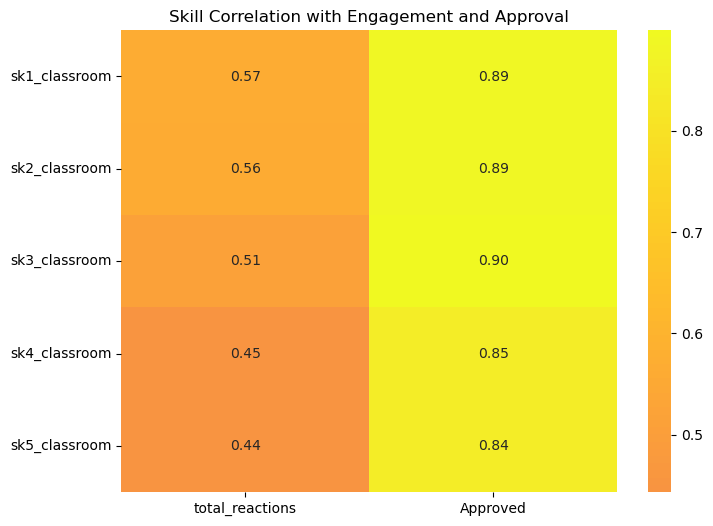

In [162]:
skill_cols = [
    "sk1_classroom",
    "sk2_classroom",
    "sk3_classroom",
    "sk4_classroom",
    "sk5_classroom"
]

# Correlation matrix
corr_df = df[skill_cols + ['total_reactions', 'Approved']].dropna()
correlation = corr_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(correlation.loc[skill_cols, ['total_reactions', 'Approved']],
    annot=True,
    cmap='plasma',
    center=0,
    fmt=".2f"
)

plt.title('Skill Correlation with Engagement and Approval')
plt.show()

### Which factors (skills, reactions, engagement) are most strongly related to being approved in the class?

Factors most related to approval:
skill_average              0.920713
positive_reaction_ratio    0.650037
reactions_per_posts        0.617393
timeonline                 0.568298
total_posts                0.439544
total_reactions            0.436846
positive_reactions         0.434348
negative_reactions         0.272815
Name: Approved, dtype: float64


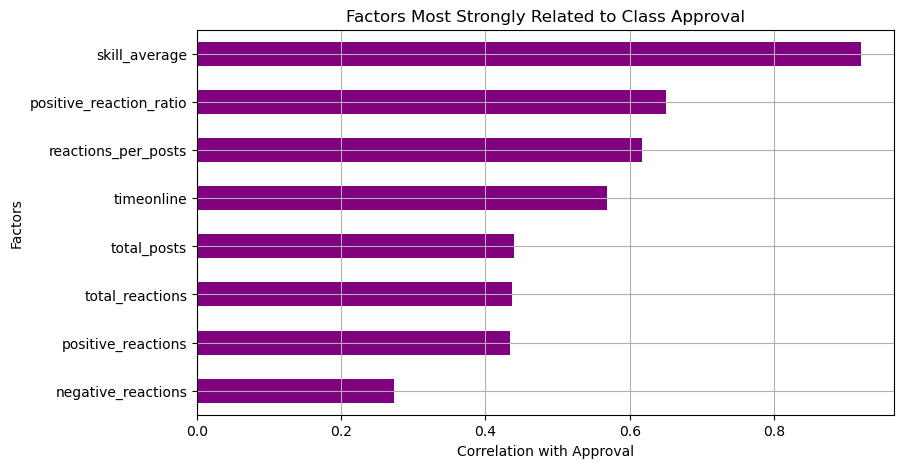

In [163]:

approval_factors = [
    'Approved',
    'timeonline',
    'total_posts',
    'total_reactions',
    'positive_reactions',
    'negative_reactions',
    'reactions_per_posts',
    'positive_reaction_ratio',
    'skill_average'
]

approval_df = df[approval_factors].dropna().copy()

# Correlation matrix
approval_corr = approval_df.corr()

# Ranking factors most related to Approved
approval_ranking = approval_corr['Approved'].drop('Approved').sort_values(ascending=False)

print("Factors most related to approval:")
print(approval_ranking)

# Bar chart
plt.figure(figsize=(9, 5))

approval_ranking.plot(kind='barh', color='purple')

plt.xlabel('Correlation with Approval')
plt.ylabel('Factors')
plt.title('Factors Most Strongly Related to Class Approval')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

## *Splitting Data*

In [164]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Approved"])
y = df["Approved"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Decision Tree Classifier
## Training Tree

In [165]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

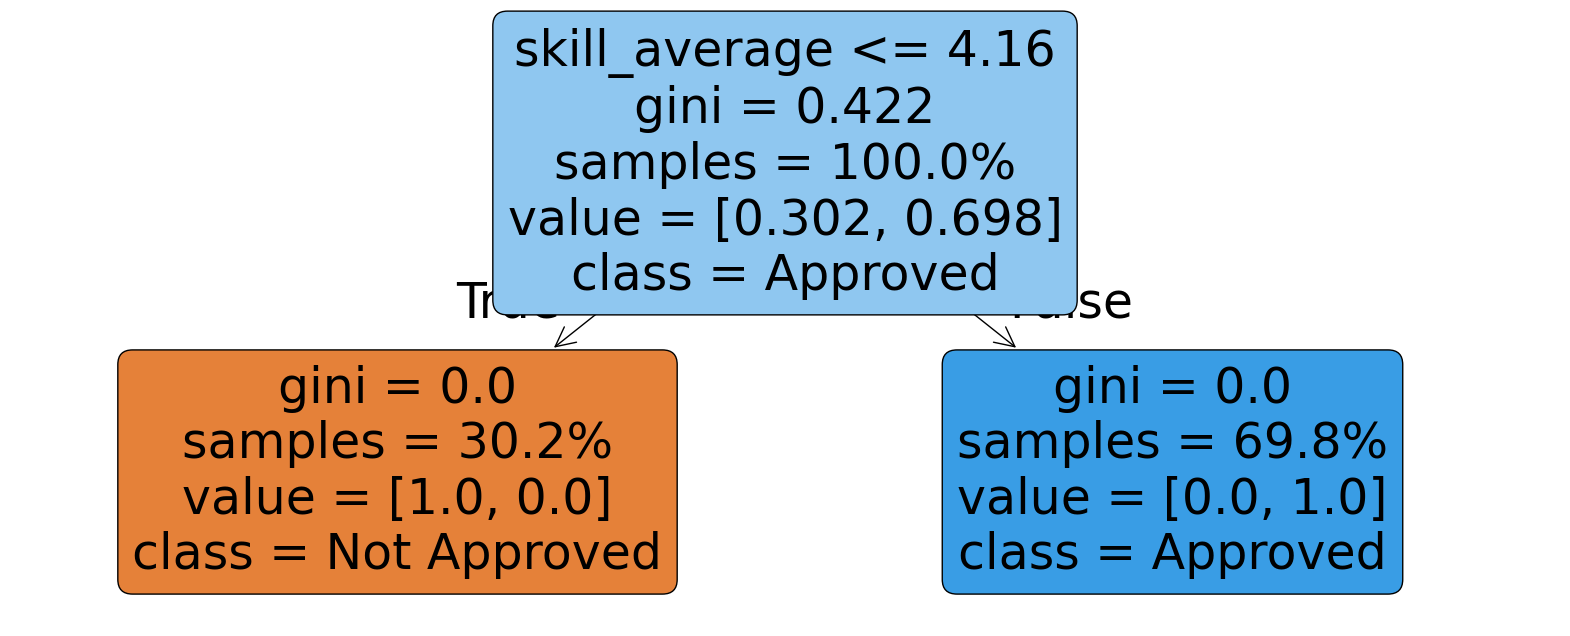

In [166]:
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

# Tree Visualization
plt.figure(figsize=(20,8))
plot_tree(tree_model, feature_names=X.columns, class_names=["Not Approved", "Approved"], filled=True, rounded=True, impurity=True, proportion=True)
plt.show()

## Tree Evaluation

In [167]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, hamming_loss, classification_report, confusion_matrix

In [168]:
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("Hamming Loss:", hamming_loss(y_test, y_pred_tree))

print("Classification Report:\n", classification_report(y_test, y_pred_tree))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tree))

Decision Tree Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Hamming Loss: 0.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        13

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

Confusion Matrix:
 [[ 5  0]
 [ 0 13]]


## Feature Importance from Decision Tree

                    Feature  Importance
19            skill_average         1.0
0               total_posts         0.0
1              helpful_post         0.0
20       reactions_per_time         0.0
18  positive_reaction_ratio         0.0
17      reactions_per_posts         0.0
16          total_reactions         0.0
15       negative_reactions         0.0
14       positive_reactions         0.0
13            sk4_classroom         0.0
12            sk3_classroom         0.0
11            sk5_classroom         0.0
10            sk2_classroom         0.0
9             sk1_classroom         0.0
8                timeonline         0.0
7              amazing_post         0.0
6                  bad_post         0.0
5             creative_post         0.0
4             confused_post         0.0
3        collaborative_post         0.0
2            nice_code_post         0.0
21                skill_std         0.0


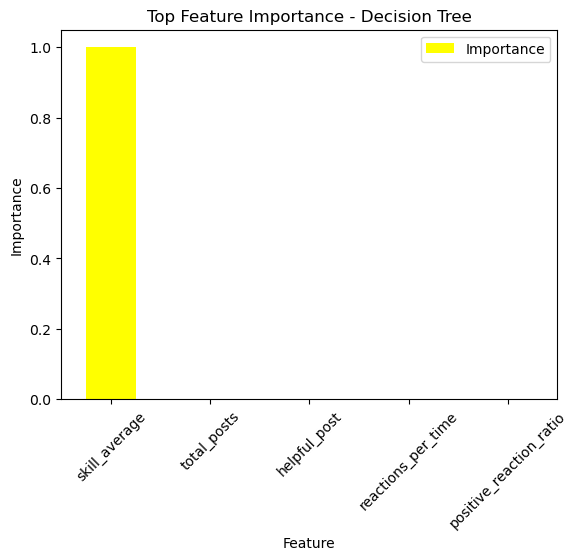

In [169]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

feature_importance.head(5).plot(x="Feature", y="Importance", kind="bar", color="yellow")
plt.title("Top Feature Importance - Decision Tree")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

# Alternative Classification Model - Random Forest
## Training Forest

In [170]:
from sklearn.ensemble import RandomForestClassifier

In [171]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)


In [172]:
print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("Hamming Loss:", hamming_loss(y_test, y_pred_rf))

print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Report:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
Hamming Loss: 0.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        13

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

Confusion Report:
 [[ 5  0]
 [ 0 13]]


## Feature Importance from Random Forest

                    Feature  Importance
19            skill_average    0.187499
10            sk2_classroom    0.157200
9             sk1_classroom    0.140870
12            sk3_classroom    0.109254
11            sk5_classroom    0.109228
14       positive_reactions    0.059438
16          total_reactions    0.045210
3        collaborative_post    0.043606
5             creative_post    0.040787
13            sk4_classroom    0.026112
7              amazing_post    0.022709
0               total_posts    0.017918
8                timeonline    0.011218
21                skill_std    0.009892
1              helpful_post    0.007619
2            nice_code_post    0.007370
15       negative_reactions    0.002262
17      reactions_per_posts    0.001807
6                  bad_post    0.000000
4             confused_post    0.000000
18  positive_reaction_ratio    0.000000
20       reactions_per_time    0.000000


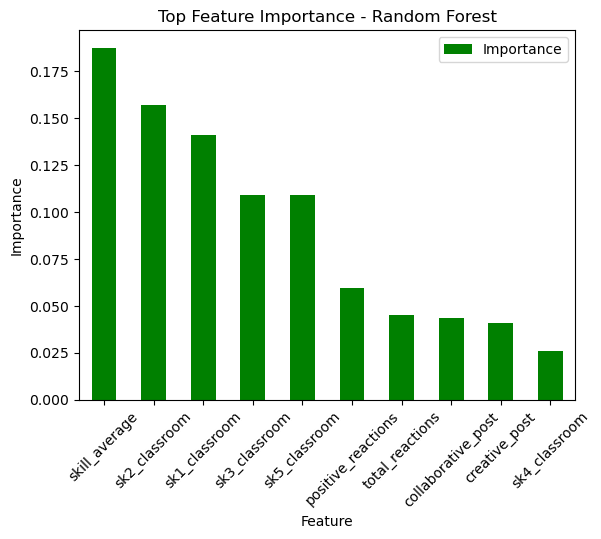

In [173]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(rf_importance)

rf_importance.head(10).plot(x="Feature", y="Importance", kind="bar", color="green")
plt.title("Top Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

### *Performance Comparison*
The decision tree and the random forest model both achieved perfect performance on this dataset, with accuracy, precision, recall, and F1-scores all equal to 1.0, and a hamming loss of 0. This indicates that both models were able to correctly classify all students in the test set without any errors. However, despite having identical performance metrics, the way each model reaches its predictions is very different, which provides important insight.
The decision tree relied entirely on a single feature, skill_average, to make predictions. The visualization shows a clear threshold (≤ 4.16), which perfectly separates students into “Approved” and “Not Approved.” This makes the decision tree highly interpretable and easy to explain, but also suggests that the model may be overly simplistic and potentially overfitting the data.
In contrast, the random forest model distributes importance across multiple features, including skill-based variables (sk1–sk5), reactions, and engagement metrics. While skill_average remains the most important feature, other variables also contribute to the prediction. This makes the random forest more robust and less sensitive to small changes in the data.
Overall, while both models perform equally well on this dataset, the decision tree offers simplicity and interpretability, whereas the random forest provides a more balanced and generalizable understanding of the details influencing student approval.

## Recommendations
The analysis shows that while increased time spent online and posting frequency do lead to higher engagement, student success (approval) is driven primarily by skill quality rather than activity alone. There is a moderate relationship between time spent online and total reactions, but the strongest relationship emerges between skill performance, especially self-learning, creativity, and critical thinking, and approval outcomes. 

Additionally, the quality of engagement (positive reaction ratio) is more influential than the sheer volume of reactions. High-time students tend to receive more meaningful reactions, such as “creative” and “amazing,” reinforcing that valuable contributions attract stronger peer recognition. 
The findings suggest that students benefit most from focusing on high-quality, thoughtful participation rather than simply increasing activity. Therefore, recommendations include encouraging students to prioritize meaningful contributions, guiding instructors to reward quality over quantity, and designing platforms that highlight impactful engagement rather than just activity metrics.